In [1]:
!pip -q install torch torchvision matplotlib pillow

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from PIL import Image
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


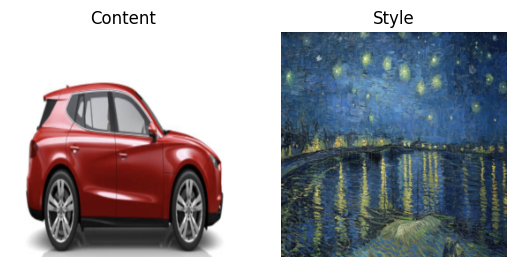

In [2]:
def load_image(path, size=256):
    image = Image.open(path).convert("RGB")
    transform = transforms.Compose([
        transforms.Resize((size, size)),
        transforms.ToTensor()
    ])
    image = transform(image).unsqueeze(0)
    return image.to(device)

content = load_image("content.jpg")
style = load_image("style.jpg")

plt.subplot(1,2,1)
plt.title("Content")
plt.imshow(content.cpu().squeeze().permute(1,2,0))
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Style")
plt.imshow(style.cpu().squeeze().permute(1,2,0))
plt.axis("off")

plt.show()

In [3]:
vgg = models.vgg19(pretrained=True).features.to(device).eval()

for param in vgg.parameters():
    param.requires_grad = False

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:05<00:00, 101MB/s]


In [4]:
def get_features(x, model):
    layers = {
        '0': 'conv1_1',
        '5': 'conv2_1',
        '10': 'conv3_1',
        '19': 'conv4_1',
        '21': 'conv4_2',
        '28': 'conv5_1'
    }

    features = {}
    for name, layer in model._modules.items():
        x = layer(x)
        if name in layers:
            features[layers[name]] = x
    return features

In [5]:
def gram_matrix(tensor):
    b, c, h, w = tensor.size()
    tensor = tensor.view(c, h*w)
    gram = torch.mm(tensor, tensor.t())
    return gram

In [6]:
content_features = get_features(content, vgg)
style_features = get_features(style, vgg)

style_grams = {layer: gram_matrix(style_features[layer]) for layer in style_features}

In [7]:
target = content.clone().requires_grad_(True).to(device)

In [10]:
optimizer = optim.Adam([target], lr=0.003)

content_weight = 1e3
style_weight = 1e5

epochs = 400

for i in range(epochs):
    target_features = get_features(target, vgg)

    content_loss = torch.mean((target_features['conv4_2'] - content_features['conv4_2'])**2)

    style_loss = 0
    for layer in style_features:
        target_feature = target_features[layer]
        target_gram = gram_matrix(target_feature)
        style_gram = style_grams[layer]

        _, c, h, w = target_feature.shape
        style_loss += torch.mean((target_gram - style_gram)**2) / (c*h*w)

    total_loss = content_weight * content_loss + style_weight * style_loss

    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

    if i % 50 == 0:
        print(f"Step {i}, Loss {total_loss.item():.4f}")

Step 0, Loss 884967.7500
Step 50, Loss 85010.5156
Step 100, Loss 59658.1953
Step 150, Loss 48236.5195
Step 200, Loss 40929.7695
Step 250, Loss 35538.8281
Step 300, Loss 31247.3750
Step 350, Loss 27800.7285


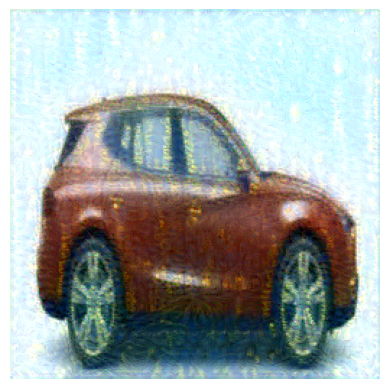

In [11]:
result = target.cpu().detach().squeeze().permute(1,2,0)

plt.imshow(result)
plt.axis("off")

plt.savefig("nst_result.png", dpi=300, bbox_inches="tight")
plt.show()